# 06 · Market Basket Analysis

**Phase 10 of the brief.** Which products travel together in the same basket?

Association rule mining on this dataset has one structural problem that has to be solved
before any mining happens: **3.35M baskets × 49,573 products** is a 166-billion-cell matrix.
Mining it directly is not possible, and the usual shortcut — "just take the top 50
products" — produces rules that only describe bananas.

The approach taken here:

| decision | choice | reason |
|---|---|---|
| algorithm | **FP-Growth** | same results as Apriori but builds a prefix tree instead of making a pass per itemset size. On 600k baskets Apriori's repeated scans are the bottleneck. |
| basket universe | **600,000 randomly sampled baskets** (seed 42) | 18% of all baskets; large enough that a 0.1% support rule still rests on ~600 real baskets. Support is then an honest "share of sampled baskets". |
| product scope | **top 300 products** | 35.6% of all units; 65.4% of baskets contain ≥2 of them. Below this the matrix explodes; above it the support floor gets meaningless. |
| second pass | **all 134 aisles**, no truncation | product-level rules answer "what to recommend"; aisle-level rules answer "what shelves belong together" — a different and often more actionable question. |

Baskets that contain none of the 300 products are **kept in the denominator**, so support
is never inflated by quietly shrinking the universe.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import instacart as ic, mba
plt = ic.set_style()
pd.set_option("display.width", 200, "display.max_columns", 30, "display.max_colwidth", 52)

items = ic.load_clean("order_items", columns=["order_id","product_uid","aisle_id","department_id"])
prods, aisles, depts = ic.load_lookups()
pname = {str(k): v for k, v in zip(prods.product_id, prods.product_name)}
aname = {str(k): v for k, v in zip(aisles.aisle_id, aisles.aisle)}
print(f"{items.order_id.nunique():,} baskets | {items.product_uid.nunique():,} products")

3,346,083 baskets | 49,573 products


## 6.1 The three metrics, on this data

Before mining, it is worth being precise about what each number will mean here, because
all three are routinely misread.

**Support** — the share of baskets containing the itemset.
`support(A→B) = baskets containing both A and B ÷ all baskets`
On a 49,573-product catalogue, support is *inherently tiny*. Even the best-selling product
in the world appears in only 14.7% of baskets. A pair at 2% support is strong here.

**Confidence** — of the baskets containing A, the share that also contain B.
`confidence(A→B) = support(A ∪ B) ÷ support(A)`
Confidence is **directional** and it is **biased toward popular consequents**: "anything →
Banana" scores well simply because bananas are everywhere. Confidence alone is a trap.

**Lift** — how much more often A and B occur together than if they were independent.
`lift(A→B) = confidence(A→B) ÷ support(B)`
Lift > 1 is a positive association; lift = 1 is independence. Lift corrects exactly the
bias that fools confidence, which is why it drives the ranking below.

In [2]:
# Worked example on the real numbers, so the metrics are concrete rather than abstract.
bids = mba.sample_baskets(items, 600_000)
n = len(bids)
sub = items[items.order_id.isin(bids)]
sets = sub.groupby("order_id").product_uid.apply(set)
A, B = 24852, 13176   # Banana, Bag of Organic Bananas
a_id, b_id = 21137, 47209   # Organic Strawberries, Organic Hass Avocado
sA = sets.map(lambda s: a_id in s).mean()
sB = sets.map(lambda s: b_id in s).mean()
sAB = sets.map(lambda s: a_id in s and b_id in s).mean()
print(f"Worked example: A = {pname[str(a_id)]}, B = {pname[str(b_id)]}")
print(f"  support(A)    = {sA:.4f}   ({sA*n:,.0f} of {n:,} baskets)")
print(f"  support(B)    = {sB:.4f}   ({sB*n:,.0f} baskets)")
print(f"  support(A∪B)  = {sAB:.4f}   ({sAB*n:,.0f} baskets)")
print(f"  confidence(A→B) = {sAB/sA:.4f}  — of baskets with strawberries, {sAB/sA*100:.1f}% also have avocado")
print(f"  lift(A→B)       = {(sAB/sA)/sB:.3f}  — {(sAB/sA)/sB:.2f}× more often than chance")

Worked example: A = Organic Strawberries, B = Organic Hass Avocado
  support(A)    = 0.0824   (49,461 of 600,000 baskets)
  support(B)    = 0.0665   (39,926 baskets)
  support(A∪B)  = 0.0127   (7,612 baskets)
  confidence(A→B) = 0.1539  — of baskets with strawberries, 15.4% also have avocado
  lift(A→B)       = 2.313  — 2.31× more often than chance


## 6.2 Choosing the thresholds

The brief asks for the thresholds to be justified from the characteristics of the data
rather than picked by habit. Here is the sensitivity run that justified them:

In [3]:
freqp = items.product_uid.value_counts()
keep = freqp.head(300).index.to_numpy()
print(f"top 300 products cover {freqp.head(300).sum()/len(items)*100:.1f}% of all units; "
      f"{(items[items.product_uid.isin(keep)].groupby('order_id').size()>=2).sum()/items.order_id.nunique()*100:.1f}% of baskets hold ≥2 of them")
P = mba.build_matrix(items, bids, "product_uid", keep_items=keep)
print(f"basket × product matrix: {P.shape}, density {P.sparse.density:.4f}")

rows = []
for ms in [0.005, 0.002, 0.001, 0.0005]:
    for mc in [0.20, 0.10, 0.05]:
        f, r = mba.mine(P, min_support=ms, min_confidence=mc, min_lift=1.0, max_len=3)
        rows.append({"min_support": ms, "min_baskets": int(ms*n), "min_confidence": mc,
                     "itemsets": len(f), "rules": len(r)})
sens = pd.DataFrame(rows)
ic.savetable(sens, "mba_threshold_sensitivity")
display(sens)

top 300 products cover 35.6% of all units; 65.4% of baskets hold ≥2 of them


basket × product matrix: (600000, 300), density 0.0120


  table  -> reports/tables/mba_threshold_sensitivity.csv  (12 rows)


,min_support,min_baskets,min_confidence,itemsets,rules
0,0.0050,3000,0.20,326,37
1,0.0050,3000,0.10,326,92
2,0.0050,3000,0.05,326,134
3,0.0020,1200,0.20,899,219
4,0.0020,1200,0.10,899,596
5,0.0020,1200,0.05,899,900
6,0.0010,600,0.20,2401,714
7,0.0010,600,0.10,2401,1785
8,0.0010,600,0.05,2401,3048
9,0.0005,300,0.20,6470,2137


**Thresholds chosen: min support 0.001, min confidence 0.05, min lift 1.0.**

* **Support 0.001** = a rule must hold in at least **600 of the 600,000 sampled baskets**.
  At 0.005 only 95 rules survive and they are all banana pairs; at 0.0005 the rule count
  explodes into pairs too rare to merchandise against. 0.001 is the point where
  non-obvious structure appears while every rule still rests on hundreds of real baskets.
* **Confidence 0.05** is deliberately *low*. With a median basket of 8 items drawn from
  49,573 products, a 5% conditional probability is a strong signal — demanding the textbook
  50% would return only tautologies. Lift, not confidence, does the ranking.
* **Lift ≥ 1.0** keeps only positive associations; anything at or below 1 is independence
  or avoidance and carries no cross-sell value.

In [4]:
freqP, rulesP = mba.mine(P, min_support=0.001, min_confidence=0.05, min_lift=1.0, max_len=3)
LP = mba.label_rules(rulesP, pname); ic.savetable(LP, "mba_rules_product")
print(f"{len(freqP):,} frequent itemsets → {len(LP):,} association rules "
      f"(the brief asks for a minimum of 10)")

  table  -> reports/tables/mba_rules_product.csv  (3,048 rows)
2,401 frequent itemsets → 3,048 association rules (the brief asks for a minimum of 10)


## 6.3 Phase 13.4 — Association rules

### Required output table: the top rules by lift

In [5]:
out = LP.head(15)[["antecedent","consequent","support","confidence","lift"]].copy()
out["support"] = (out.support*100).round(2).astype(str)+"%"
out["confidence"] = (out.confidence*100).round(1).astype(str)+"%"
out["lift"] = out.lift.round(2)
display(out.style.hide(axis="index"))

antecedent,consequent,support,confidence,lift
Icelandic Style Skyr Blueberry Non-fat Yogurt,Non Fat Raspberry Yogurt,0.22%,38.0%,75.610000
Non Fat Raspberry Yogurt,Icelandic Style Skyr Blueberry Non-fat Yogurt,0.22%,44.4%,75.610000
Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.12%,46.9%,75.580000
Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt with Peach,0.12%,18.6%,75.580000
Total 2% with Strawberry Lowfat Greek Strained Yogurt,Total 2% Lowfat Greek Strained Yogurt with Peach + Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.12%,12.8%,68.120000
Total 2% Lowfat Greek Strained Yogurt with Peach + Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.12%,61.6%,68.120000
Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.12%,18.7%,66.940000
Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% Lowfat Greek Strained Yogurt with Peach,0.12%,41.3%,66.940000
Icelandic Style Skyr Blueberry Non-fat Yogurt,Vanilla Skyr Nonfat Yogurt,0.21%,35.0%,61.050000
Vanilla Skyr Nonfat Yogurt,Icelandic Style Skyr Blueberry Non-fat Yogurt,0.21%,35.9%,61.050000


### The same rules ranked by support — a completely different list

In [6]:
display(LP.nlargest(12,"support")[["antecedent","consequent","support","confidence","lift"]]
        .style.format({"support":"{:.2%}","confidence":"{:.1%}","lift":"{:.2f}"}).hide(axis="index"))

antecedent,consequent,support,confidence,lift
Bag of Organic Bananas,Organic Strawberries,1.95%,16.4%,1.99
Organic Strawberries,Bag of Organic Bananas,1.95%,23.7%,1.99
Organic Hass Avocado,Bag of Organic Bananas,1.94%,29.1%,2.45
Bag of Organic Bananas,Organic Hass Avocado,1.94%,16.3%,2.45
Banana,Organic Strawberries,1.74%,11.8%,1.44
Organic Strawberries,Banana,1.74%,21.1%,1.44
Organic Avocado,Banana,1.65%,30.0%,2.04
Banana,Organic Avocado,1.65%,11.2%,2.04
Organic Baby Spinach,Banana,1.61%,21.3%,1.45
Banana,Organic Baby Spinach,1.61%,10.9%,1.45


findfont: Failed to find font weight 600 for DejaVu Sans, now using 700.


  figure -> reports/figures/06_rules_scatter.png


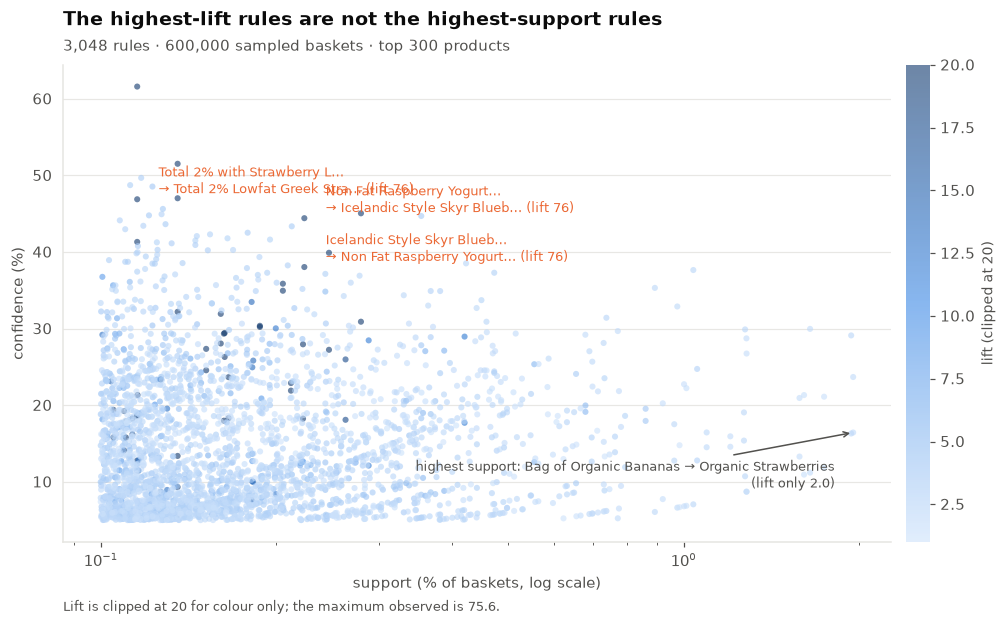

In [7]:
fig, ax = plt.subplots(figsize=(9.8, 5.8))
sc = ax.scatter(LP.support*100, LP.confidence*100, c=np.clip(LP.lift, 1, 20),
                cmap=ic.seq_cmap(), s=16, alpha=.6, edgecolors="none")
cb = fig.colorbar(sc, ax=ax, pad=.015); cb.set_label("lift (clipped at 20)", color=ic.PALETTE["muted"], fontsize=9)
cb.outline.set_visible(False)
ax.set_xscale("log")
hi = LP.nlargest(3, "lift")
for _, r in hi.iterrows():
    ax.annotate(f"{r.antecedent[:26]}…\n→ {r.consequent[:26]}… (lift {r.lift:.0f})",
                (r.support*100, r.confidence*100), xytext=(14, 4), textcoords="offset points",
                fontsize=8.5, color=ic.PALETTE["s2"])
big = LP.nlargest(1, "support").iloc[0]
ax.annotate(f"highest support: {big.antecedent} → {big.consequent}\n(lift only {big.lift:.1f})",
            (big.support*100, big.confidence*100), xytext=(-12, -36), textcoords="offset points",
            fontsize=8.5, color=ic.PALETTE["muted"], ha="right",
            arrowprops=dict(arrowstyle="->", color=ic.PALETTE["muted"], lw=1))
ic.finish(ax, "The highest-lift rules are not the highest-support rules",
          f"{len(LP):,} rules · 600,000 sampled baskets · top 300 products",
          "support (% of baskets, log scale)", "confidence (%)",
          source="Lift is clipped at 20 for colour only; the maximum observed is 75.6.")
fig.tight_layout(); ic.savefig(fig, "06_rules_scatter"); plt.show()

## 6.4 Phase 13.5 — Business interpretation

The rules fall into **three distinct commercial patterns**, and conflating them would lead
to three wrong decisions. Each is examined separately.

### Pattern 1 — Flavour variety within one brand line (lift 30–76)

Every one of the highest-lift rules in the dataset has this shape:

In [8]:
yog = LP[LP.antecedent.str.contains("Yogurt|Skyr", case=False) &
         LP.consequent.str.contains("Yogurt|Skyr", case=False)].head(8)
display(yog[["antecedent","consequent","support","confidence","lift"]]
        .style.format({"support":"{:.2%}","confidence":"{:.1%}","lift":"{:.1f}"}).hide(axis="index"))
spark = LP[LP.antecedent.str.contains("Sparkling", case=False) &
           LP.consequent.str.contains("Sparkling", case=False)].head(4)
display(spark[["antecedent","consequent","support","confidence","lift"]]
        .style.format({"support":"{:.2%}","confidence":"{:.1%}","lift":"{:.1f}"}).hide(axis="index"))

antecedent,consequent,support,confidence,lift
Icelandic Style Skyr Blueberry Non-fat Yogurt,Non Fat Raspberry Yogurt,0.22%,38.0%,75.6
Non Fat Raspberry Yogurt,Icelandic Style Skyr Blueberry Non-fat Yogurt,0.22%,44.4%,75.6
Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.12%,46.9%,75.6
Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt with Peach,0.12%,18.6%,75.6
Total 2% with Strawberry Lowfat Greek Strained Yogurt,Total 2% Lowfat Greek Strained Yogurt with Peach + Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.12%,12.8%,68.1
Total 2% Lowfat Greek Strained Yogurt with Peach + Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% with Strawberry Lowfat Greek Strained Yogurt,0.12%,61.6%,68.1
Total 2% Lowfat Greek Strained Yogurt with Peach,Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt With Blueberry,0.12%,18.7%,66.9
Total 2% with Strawberry Lowfat Greek Strained Yogurt + Total 2% Lowfat Greek Strained Yogurt With Blueberry,Total 2% Lowfat Greek Strained Yogurt with Peach,0.12%,41.3%,66.9


antecedent,consequent,support,confidence,lift
Sparkling Lemon Water + Sparkling Water Grapefruit,Lime Sparkling Water,0.14%,47.0%,32.4
Lime Sparkling Water,Sparkling Lemon Water + Sparkling Water Grapefruit,0.14%,9.3%,32.4
Lime Sparkling Water + Sparkling Water Grapefruit,Sparkling Lemon Water,0.14%,32.2%,31.8
Sparkling Lemon Water,Lime Sparkling Water + Sparkling Water Grapefruit,0.14%,13.4%,31.8


**Finding.** The strongest association in the entire dataset is between *different flavours
of the same yogurt brand*: Total 2% Greek Strained Yogurt with Blueberry → with Strawberry
+ with Peach has a **lift of 75.6**. Siggi's-style skyr flavours show the same pattern
(lift 75.6, 61.0, 55.8), as do sparkling water flavours (lift 32.4, 21.7).

**Evidence.** Confidence reaches **61.6%** on one of these: six in ten baskets containing
peach + blueberry Total 2% also contain the strawberry variant.

**Business meaning — and the trap.** These are *not* cross-sell opportunities. The customer
has already decided to buy this brand; the rule describes them assembling a mixed pack
inside a decision they have already made. Recommending strawberry yogurt to someone who
just added blueberry yogurt adds nothing they were not about to do.

What it *is* worth, and the actions are quite different from recommendation:
* **Bundle/multipack** — a "pick any 4 flavours" pack converts four separate line items
  into one, directly reducing pick time and packing cost on an item customers already buy together.
* **Range discipline** — these products are bought as a *set*. Delisting one flavour will
  damage sales of the others, which a per-SKU profitability review would never reveal.
* **Substitution logic** — if blueberry is out of stock, the right substitute is
  demonstrably strawberry from the same line, not another brand's blueberry.

### Pattern 2 — Recipe and meal complements (lift 3–6)

These are the genuine cross-sell rules. They are found by looking at pairwise lift among
the best-selling products, where every item is individually popular — so a high lift cannot
be an artefact of rarity.

In [9]:
top30 = [str(c) for c in freqp.head(30).index if str(c) in P.columns]
LM = mba.pair_lift_matrix(P, top30)
LMn = LM.rename(index=pname, columns=pname)
LMn.to_csv(ic.TABLES/"mba_pair_lift_top30.csv")
s = LM.stack().sort_values(ascending=False)
seen, pairs = set(), []
for (a, b), v in s.items():
    k = frozenset((a, b))
    if k in seen: continue
    seen.add(k); pairs.append({"product A": pname[a], "product B": pname[b], "lift": v})
    if len(pairs) == 14: break
display(pd.DataFrame(pairs).style.format({"lift":"{:.2f}"}).hide(axis="index"))

product A,product B,lift
Organic Garlic,Organic Yellow Onion,5.64
Limes,Large Lemon,4.08
Organic Cucumber,Organic Grape Tomatoes,3.77
Organic Lemon,Organic Cucumber,3.75
Organic Lemon,Organic Hass Avocado,3.62
Yellow Onions,Organic Garlic,3.57
Organic Garlic,Organic Lemon,3.50
Organic Lemon,Organic Yellow Onion,3.39
Limes,Organic Garlic,3.29
Organic Yellow Onion,Organic Zucchini,3.25


  figure -> reports/figures/06_pair_lift_heatmap.png


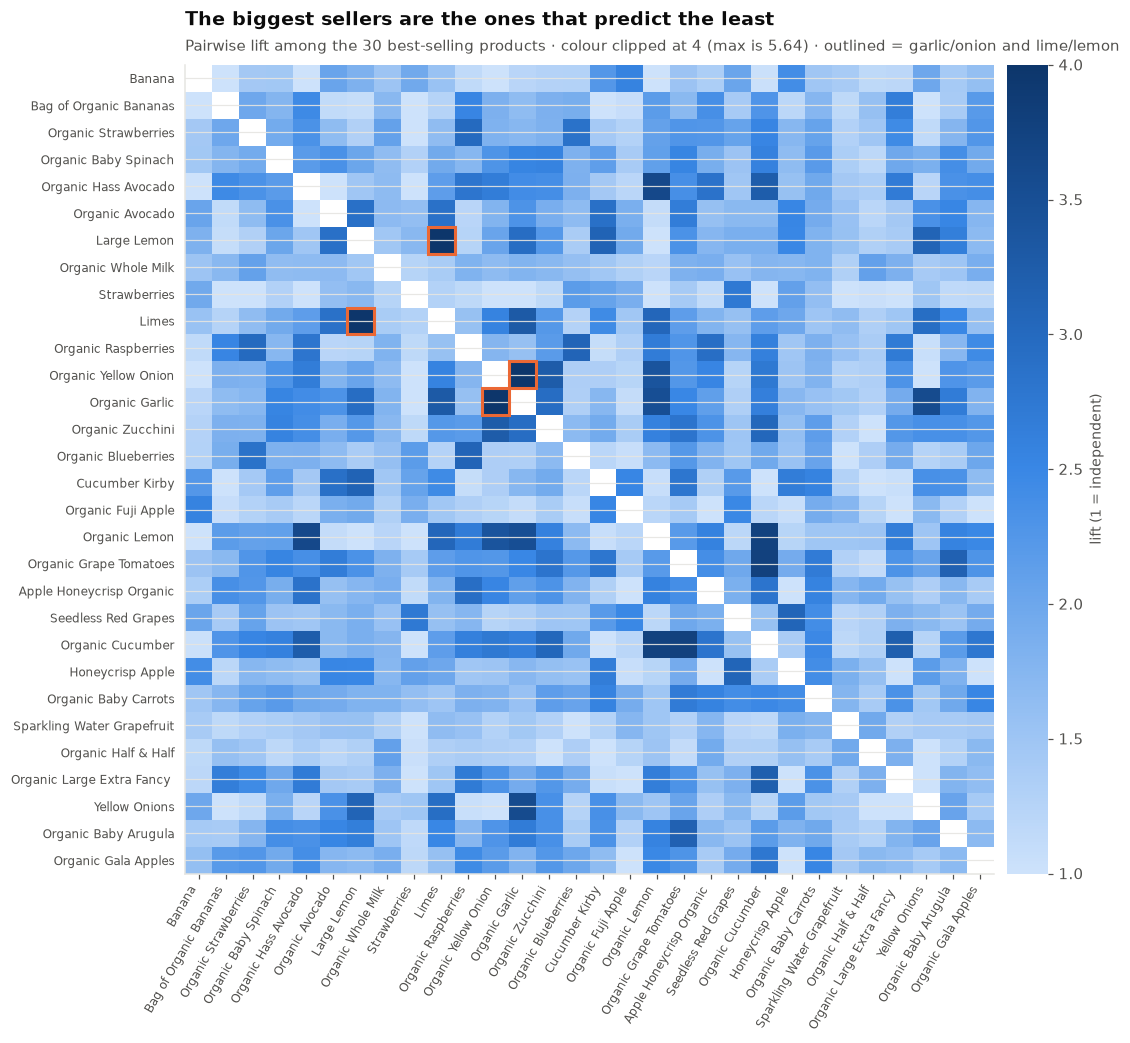

In [10]:
order_by_vol = [pname[c] for c in top30]
M = LMn.loc[order_by_vol, order_by_vol]
fig, ax = plt.subplots(figsize=(11.6, 9.6))
im = ax.imshow(M.values, cmap=ic.seq_cmap(), vmin=1, vmax=4)
ax.set_xticks(range(len(M))); ax.set_xticklabels([t[:26] for t in M.columns], rotation=60, ha="right", fontsize=8)
ax.set_yticks(range(len(M))); ax.set_yticklabels([t[:26] for t in M.index], fontsize=8)
cb = fig.colorbar(im, ax=ax, pad=.012, fraction=.038)
cb.set_label("lift (1 = independent)", color=ic.PALETTE["muted"], fontsize=9); cb.outline.set_visible(False)
for (a, b) in [("Organic Garlic","Organic Yellow Onion"), ("Limes","Large Lemon")]:
    i, j = list(M.index).index(a), list(M.columns).index(b)
    ax.add_patch(plt.Rectangle((j-.5, i-.5), 1, 1, fill=False, edgecolor=ic.PALETTE["s2"], lw=2))
    ax.add_patch(plt.Rectangle((i-.5, j-.5), 1, 1, fill=False, edgecolor=ic.PALETTE["s2"], lw=2))
ax.grid(False)
ic.finish(ax, "The biggest sellers are the ones that predict the least",
          "Pairwise lift among the 30 best-selling products · colour clipped at 4 (max is 5.64)"
          " · outlined = garlic/onion and lime/lemon", "", "")
fig.tight_layout(); ic.savefig(fig, "06_pair_lift_heatmap"); plt.show()

The banana rows are the palest in the matrix, and that is the point: bananas are in
14.7% of baskets, so they co-occur with everything and predict nothing.

**Finding.** Among the thirty best sellers — all individually popular, so rarity cannot
explain anything — the strongest pairs are unmistakably **culinary**:

| pair | lift | what it is |
|---|---|---|
| Organic Garlic ↔ Organic Yellow Onion | **5.64** | the base of nearly every savoury recipe |
| Limes ↔ Large Lemon | **4.08** | citrus, bought together for cooking and drinks |
| Organic Cucumber ↔ Organic Grape Tomatoes | **3.77** | salad |
| Organic Lemon ↔ Organic Cucumber | 3.75 | salad / infused water |
| Organic Lemon ↔ Organic Hass Avocado | 3.62 | guacamole, dressings |
| Yellow Onions ↔ Organic Garlic | 3.57 | as above, non-organic variant |

The heatmap shows this as a visible block: the aromatics and salad vegetables light up
against each other, while bananas — the single biggest seller — are **pale against
everything**. Bananas are bought by everyone, so they are associated with nothing in particular.

**Business meaning.** These are real cross-sell opportunities because the customer's
intent (*cook a meal*) is only partly expressed by the first item. Concretely:
* **Recipe bundles** — "aromatics starter" (garlic, onion), "salad kit" (cucumber,
  tomatoes, lemon), "guacamole kit" (avocado, lime, onion). Each is evidenced by a lift
  above 3.5 among products the customer already buys.
* **Basket completion prompts** — adding garlic without onion is the single most
  informative gap in the dataset, and the prompt is genuinely useful rather than intrusive.
* **Co-location** — in a warehouse pick path, these items should sit near each other.

And the negative finding matters commercially: **recommending bananas is worthless**. Their
high support guarantees they will top any confidence-ranked recommendation list while
adding no information. 21.5% of all mined rules have a banana as the consequent — a
recommender built on confidence would recommend almost nothing else.

### Pattern 3 — Category adjacency (aisle level)

Product-level rules answer "what to show this customer next". Aisle-level rules answer a
different question — "which parts of the store belong together" — and because there are
only 134 aisles, no truncation is needed and support is far more robust.

In [11]:
A = mba.build_matrix(items, bids, "aisle_id")
print(f"basket × aisle matrix: {A.shape}, density {A.sparse.density:.4f}")
freqA, rulesA = mba.mine(A, min_support=0.01, min_confidence=0.20, min_lift=1.0, max_len=3)
LA = mba.label_rules(rulesA, aname); ic.savetable(LA, "mba_rules_aisle")
print(f"{len(freqA):,} frequent itemsets → {len(LA):,} aisle rules (support ≥1%, confidence ≥20%)")
display(LA.head(12)[["antecedent","consequent","support","confidence","lift"]]
        .style.format({"support":"{:.2%}","confidence":"{:.1%}","lift":"{:.2f}"}).hide(axis="index"))

basket × aisle matrix: (600000, 134), density 0.0543


  table  -> reports/tables/mba_rules_aisle.csv  (3,692 rows)
2,135 frequent itemsets → 3,692 aisle rules (support ≥1%, confidence ≥20%)


antecedent,consequent,support,confidence,lift
packaged vegetables fruits + dry pasta,pasta sauce,1.07%,29.0%,4.66
packaged vegetables fruits + pasta sauce,dry pasta,1.07%,32.7%,4.58
fresh vegetables + pasta sauce,dry pasta,1.32%,32.2%,4.52
fresh fruits + pasta sauce,dry pasta,1.34%,31.7%,4.44
dry pasta + fresh fruits,pasta sauce,1.34%,27.6%,4.44
pasta sauce,dry pasta + fresh fruits,1.34%,21.6%,4.44
dry pasta + fresh vegetables,pasta sauce,1.32%,27.4%,4.41
pasta sauce,dry pasta + fresh vegetables,1.32%,21.2%,4.41
dry pasta,pasta sauce,1.95%,27.4%,4.41
pasta sauce,dry pasta,1.95%,31.4%,4.41


  figure -> reports/figures/06_aisle_rules.png


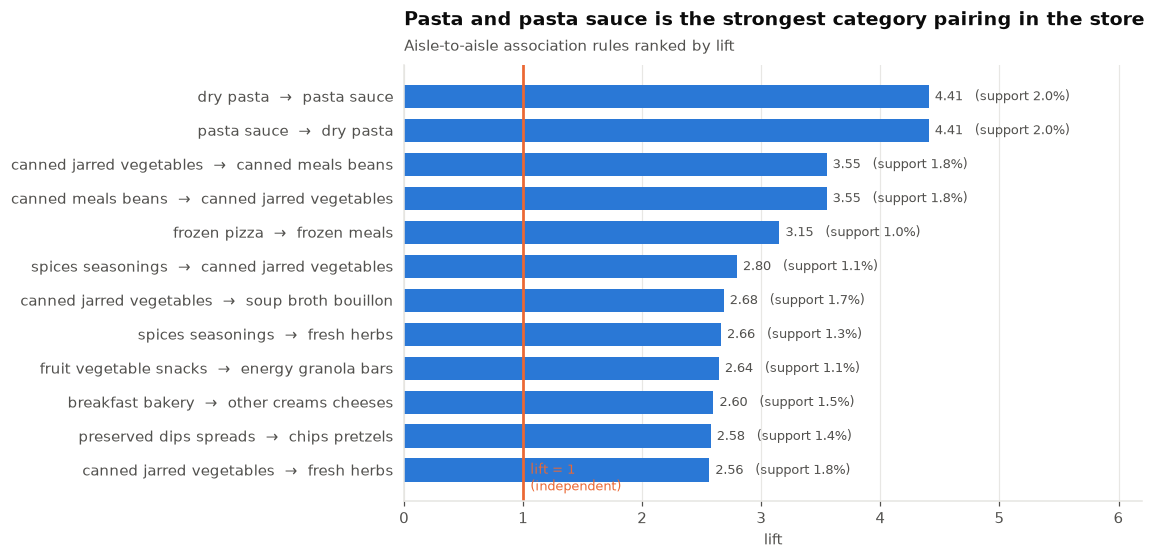

In [12]:
pair_rules = LA[(LA.antecedent.str.count(r"\+")==0) & (LA.consequent.str.count(r"\+")==0)].head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(10.6, 5.2))
lbl = [f"{a}  →  {b}" for a, b in zip(pair_rules.antecedent, pair_rules.consequent)]
ax.barh(lbl, pair_rules.lift, color=ic.PALETTE["s1"], height=.68)
ax.axvline(1, color=ic.PALETTE["s2"], lw=1.8)
ax.text(1.06, -.6, "lift = 1\n(independent)", color=ic.PALETTE["s2"], fontsize=8.5)
for i, (v, s_) in enumerate(zip(pair_rules.lift, pair_rules.support)):
    ax.text(v+.05, i, f"{v:.2f}   (support {s_*100:.1f}%)", va="center", fontsize=8.5, color=ic.PALETTE["muted"])
ic.finish(ax, "Pasta and pasta sauce is the strongest category pairing in the store",
          "Aisle-to-aisle association rules ranked by lift", "lift", "", xgrid=True)
ax.set_xlim(0, 6.2)
fig.tight_layout(); ic.savefig(fig, "06_aisle_rules"); plt.show()

**Finding.** The aisle rules are **meal-occasion signals**, and they are far more robust
than the product rules — these hold in 1–2% of *all* baskets, not 0.1%:

* **dry pasta ↔ pasta sauce, lift 4.41, support 1.95%** — 31.4% of baskets with pasta sauce
  contain dry pasta. This is the single clearest cross-category pairing in the dataset.
* **canned meals/beans ↔ canned jarred vegetables, lift 3.55, support 1.83%** — a
  store-cupboard shopping mode.
* **fresh herbs → fresh vegetables, confidence 84.6%** (lift 1.90, support 7.96%) — the
  highest-confidence single-antecedent rule at any level. Buying fresh herbs almost
  guarantees a fresh-vegetable basket, because herbs are never the point of the trip; they
  are an ingredient in a cooking occasion. Adding a second store-cupboard aisle to the
  antecedent strengthens it further: *fresh herbs + canned meals/beans → fresh vegetables*
  reaches **92.0%**, the highest confidence observed anywhere in this analysis.

**Business meaning.** The aisle rules identify **shopping missions** rather than product
affinities, which makes them the better basis for merchandising:
* A customer with pasta + sauce in the basket is cooking Italian tonight — parmesan, garlic
  bread and wine are the natural adjacencies, and the rule tells us *when* to offer them.
* The fresh-herbs rule works as a **mission detector**: herbs in a basket signal a
  cook-from-scratch trip, which is a different and more valuable customer state than a
  convenience top-up.
* For warehouse layout and pick-path design, the aisle lift matrix is directly actionable
  in a way the product rules are not.

## 6.5 Honest limitations of this analysis

Four things these rules do **not** support, stated so they are not over-claimed:

1. **Association is not causation.** Garlic and onion co-occur because both are in the
   recipe, not because one causes the other. A bundle will work; "promote garlic to sell
   onions" may not.
2. **Support is relative to the 600,000-basket sample and the top-300 product scope.** A
   rule at 0.1% support here would have different support on the full catalogue. The
   *ranking* is stable; the absolute support figures are scope-dependent.
3. **No price, margin or promotion data exists in this dataset.** A high-lift pair may be
   commercially worthless if both items are low-margin, and no rule here can tell us that.
   Every recommendation in notebook 07 that involves a bundle is therefore conditional on a
   margin check.
4. **No timestamps, so no seasonality.** `order_dow` and `order_hour_of_day` exist but there
   is no date. A pairing that is purely seasonal (e.g. a summer salad kit) is invisible here
   and would be averaged into the annual figure.

## 6.6 Phase 10 summary

| | Product level | Aisle level |
|---|---|---|
| Universe | 600,000 sampled baskets | 600,000 sampled baskets |
| Scope | top 300 products (35.6% of units) | all 134 aisles |
| Thresholds | support ≥ 0.1%, confidence ≥ 5%, lift ≥ 1 | support ≥ 1%, confidence ≥ 20%, lift ≥ 1 |
| Rules found | **3,048** | **3,692** |
| Max lift | 75.6 (yogurt flavour variants) | 4.66 (pasta ↔ pasta sauce) |
| Max confidence | 61.6% | 84.6% single-antecedent (fresh herbs → fresh vegetables); 92.0% with two antecedents |
| Best commercial use | recipe bundles, basket completion | shopping-mission detection, store layout |

The three patterns, and what each is actually for:

1. **Flavour variety (lift 30–76)** → multipacks, substitution logic, range protection. *Not* recommendation.
2. **Recipe complements (lift 3–6)** → cross-sell, basket completion, kit bundles. The real recommendation engine.
3. **Category adjacency (lift 3–5, high support)** → mission detection, layout, campaign timing.